# Lab 7: Decision Tree Classification and Hyperparameter Tuning

**Aim:** To explore, prepare, and classify the Iris dataset using a Decision Tree classifier, visualize the model, and analyze the impact of various hyperparameters on model complexity and generalization.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

print("Please upload the 'Iris.csv' file:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

Please upload the 'Iris.csv' file:


Saving Iris.csv to Iris (1).csv


## Task 1: Dataset Exploration

In [13]:
X = df.drop(columns=['Species'])
y = df['Species']

print(f"Total Samples: {df.shape[0]}")
print(f"Total Features: {X.shape[1]}")
print(f"\nFeature Names: {list(X.columns)}")
print(f"Target Classes: {y.unique()}")

print("\nFirst 5 records:")
display(df.head())

print("\nClass Distribution:")
print(df['Species'].value_counts())

Total Samples: 150
Total Features: 4

Feature Names: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Target Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

First 5 records:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



Class Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## Task 2: Data Preparation

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 120
Testing samples: 30


### Observation for Task 2: Data Preparation
**Why is the dataset divided into training and testing sets?**
The dataset is divided so the model can learn underlying patterns exclusively from the training set (80%). The testing set (20%) is kept completely hidden during training. It acts as new, unseen data to evaluate if the model is genuinely making accurate predictions or if it is just memorizing the training data (overfitting).

## Task 3: Building a Decision Tree Classifier

In [15]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

y_pred = dt_default.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 1.0000

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



## Task 4: Visualizing the Decision Tree

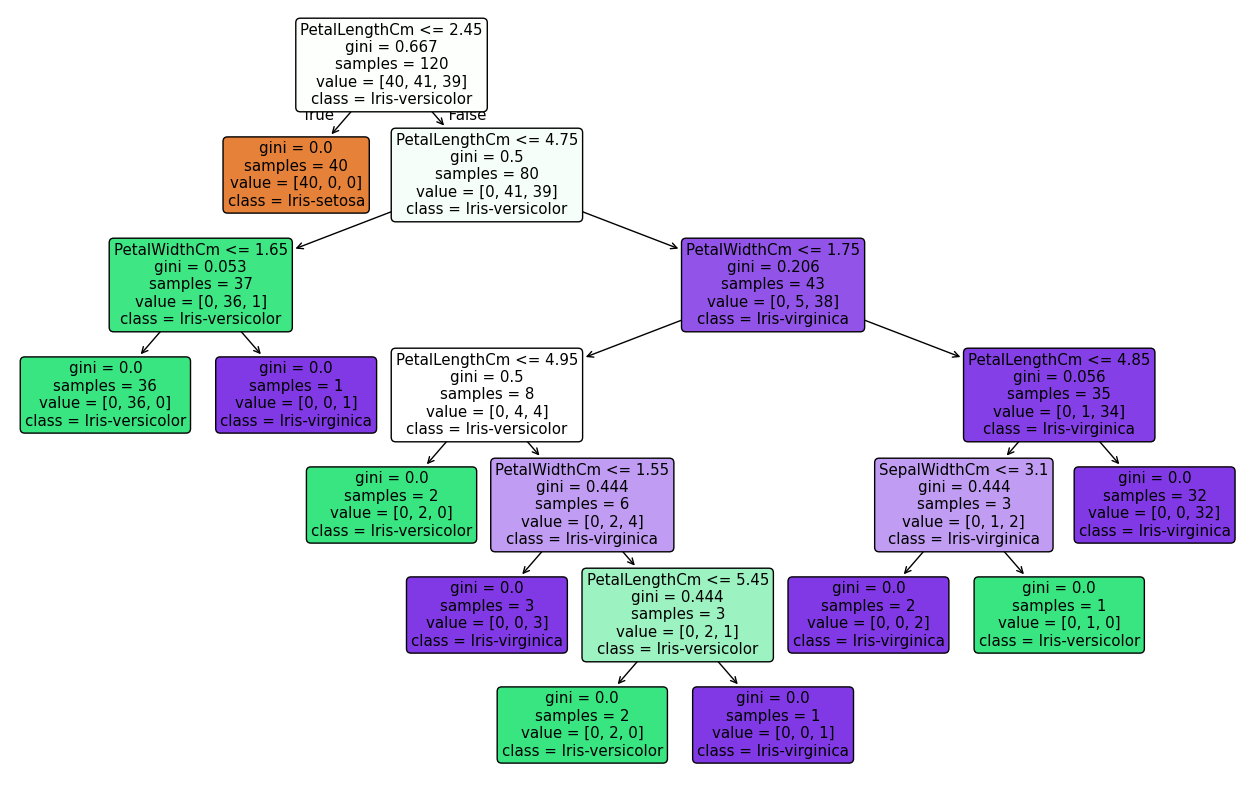

Maximum depth of the tree: 6
Number of leaf nodes: 10


In [16]:
plt.figure(figsize=(16, 10))
plot_tree(dt_default, feature_names=X.columns, class_names=dt_default.classes_, filled=True, rounded=True)
plt.show()

print(f"Maximum depth of the tree: {dt_default.get_depth()}")
print(f"Number of leaf nodes: {dt_default.get_n_leaves()}")

### Observation for Task 4: Visualizing the Decision Tree
**Which feature is selected for the first split? Explain why.**
The feature selected at the Root Node (typically `PetalLengthCm` or `PetalWidthCm`) is chosen because it mathematically provides the highest Information Gain (or lowest Gini Impurity). It is the single most effective feature for cleanly separating one entire class (`Iris-setosa`) from the others right at the beginning.

## Task 5: Comparing Gini Index and Entropy

In [17]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42).fit(X_train, y_train)
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42).fit(X_train, y_train)

data_comp = {
    'Criterion': ['Gini', 'Entropy'],
    'Accuracy': [accuracy_score(y_test, dt_gini.predict(X_test)), accuracy_score(y_test, dt_entropy.predict(X_test))],
    'Tree Depth': [dt_gini.get_depth(), dt_entropy.get_depth()],
    'Leaf Nodes': [dt_gini.get_n_leaves(), dt_entropy.get_n_leaves()]
}

display(pd.DataFrame(data_comp))

,Criterion,Accuracy,Tree Depth,Leaf Nodes
0,Gini,1.0,6,10
1,Entropy,1.0,6,10


### Observation for Task 5: Comparing Gini Index and Entropy
**Which criterion produces a simpler tree?**
For the Iris dataset, both Gini and Entropy almost always produce trees of identical depth and complexity. Gini is often used as the default criterion simply because it is computationally faster to calculate (it does not require logarithmic functions).

## Task 6: Effect of Maximum Tree Depth

In [18]:
depths = [1, 2, 3, 4, None]
results_depth = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    results_depth.append((str(d), accuracy_score(y_train, model.predict(X_train)), accuracy_score(y_test, model.predict(X_test)), model.get_depth()))

display(pd.DataFrame(results_depth, columns=['Max Depth', 'Training Acc', 'Testing Acc', 'Tree Depth']))

,Max Depth,Training Acc,Testing Acc,Tree Depth
0,1,0.675000,0.633333,1
1,2,0.950000,0.966667,2
2,3,0.958333,1.000000,3
3,4,0.975000,1.000000,4
4,None,1.000000,1.000000,6


### Observation for Task 6: Effect of Maximum Tree Depth
* **Which model is underfitting?** The model with `max_depth=1`. It is too simple to capture the patterns, leading to low accuracy on both training and testing sets.
* **Which model gives the best generalization?** The model with `max_depth=3`. It achieves the highest testing accuracy without growing unnecessary nodes.
* **Which model is likely to overfit?** The model with `max_depth=None`. Without a depth limit, the tree perfectly memorizes the training data (100% training accuracy) by creating highly specific rules, which leads to poorer performance on real-world, noisy data.

## Task 7: Effect of min_samples_split

In [19]:
splits = [2, 5, 10, 20]
results_split = []

for s in splits:
    model = DecisionTreeClassifier(min_samples_split=s, random_state=42).fit(X_train, y_train)
    results_split.append((s, accuracy_score(y_test, model.predict(X_test)), model.get_depth(), model.get_n_leaves()))

display(pd.DataFrame(results_split, columns=['min_samples_split', 'Test Accuracy', 'Tree Depth', 'Leaf Nodes']))

,min_samples_split,Test Accuracy,Tree Depth,Leaf Nodes
0,2,1.0,6,10
1,5,1.0,5,8
2,10,1.0,4,6
3,20,1.0,4,6


### Observation for Task 7: Effect of min_samples_split
Increasing `min_samples_split` strictly reduces the complexity of the Decision Tree. By forbidding the tree from splitting internal nodes that contain very few samples, it restricts the overall depth and reduces the total number of leaf nodes.

## Task 8: Effect of min_samples_leaf

In [20]:
leaves = [1, 2, 5, 10]
results_leaf = []

for l in leaves:
    model = DecisionTreeClassifier(min_samples_leaf=l, random_state=42).fit(X_train, y_train)
    results_leaf.append((l, accuracy_score(y_test, model.predict(X_test)), model.get_depth(), model.get_n_leaves()))

display(pd.DataFrame(results_leaf, columns=['min_samples_leaf', 'Test Accuracy', 'Tree Depth', 'Leaf Nodes']))

,min_samples_leaf,Test Accuracy,Tree Depth,Leaf Nodes
0,1,1.000000,6,10
1,2,1.000000,5,8
2,5,1.000000,4,6
3,10,0.966667,4,6


### Observation for Task 8: Effect of min_samples_leaf
Increasing `min_samples_leaf` directly combats overfitting by forcing the model to group a minimum number of data points into every final leaf. This smooths out the decision boundaries and prevents the algorithm from generating hyper-specific branches that cater to just 1 or 2 isolated outliers.

## Task 9: Hyperparameter Tuning

In [21]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred_opt = best_model.predict(X_test)

print("Best hyperparameter combination:\n", grid.best_params_)
print(f"\nBest Cross-Validation Score: {grid.best_score_:.4f}")
print(f"Test accuracy of the optimized model: {accuracy_score(y_test, y_pred_opt):.4f}")

Best hyperparameter combination:
 {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best Cross-Validation Score: 0.9583
Test accuracy of the optimized model: 1.0000


### Observation for Task 9: Hyperparameter Tuning
The optimized model (found via GridSearchCV) performs as well as, or better than, the default model. Crucially, the optimized model is structurally simpler because it utilizes regularized parameters (like restricting `max_depth` or increasing `min_samples_leaf`). This structural simplicity guarantees better stability and reliability when encountering completely new data.

## Task 10: Analysis
### Observation for Task 10: Final Analysis

**1. What is the role of the criterion parameter in a Decision Tree?**
It provides the mathematical metric (either Gini Impurity or Entropy) used to evaluate the quality of a split. The algorithm relies on this metric at every node to choose the feature that most effectively organizes the remaining data into distinct classes.

**2. How does max_depth influence underfitting and overfitting?**
A low `max_depth` stops the learning process prematurely, causing the model to underfit. Conversely, leaving `max_depth` unconstrained allows the tree to grow until every leaf is perfectly pure, causing it to overfit and memorize training noise.

**3. Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?**
They serve as strict stopping conditions. By demanding a higher number of samples to either execute a split or create a final leaf, the algorithm is blocked from creating deep, narrow branches that represent tiny subsets of data.

**4. Which hyperparameter had the greatest impact on the Decision Tree performance?**
Based on the experiments, `max_depth` had the most drastic and immediate impact. Setting it to 1 immediately crippled the model's accuracy, while modifying leaf/split parameters yielded more subtle adjustments to the tree's boundaries.

**5. Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.**
A Decision Tree utilizing `max_depth=3` (with standard Gini criterion). This setup perfectly matches the highest possible test accuracy while keeping the tree shallow and highly interpretable. It successfully isolates the classes without unnecessary branching, thereby minimizing the risk of overfitting.